In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
from entropy import *

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.43840390805544033 0.35866141750463654
0.03805974115734463 0.39865801059720934


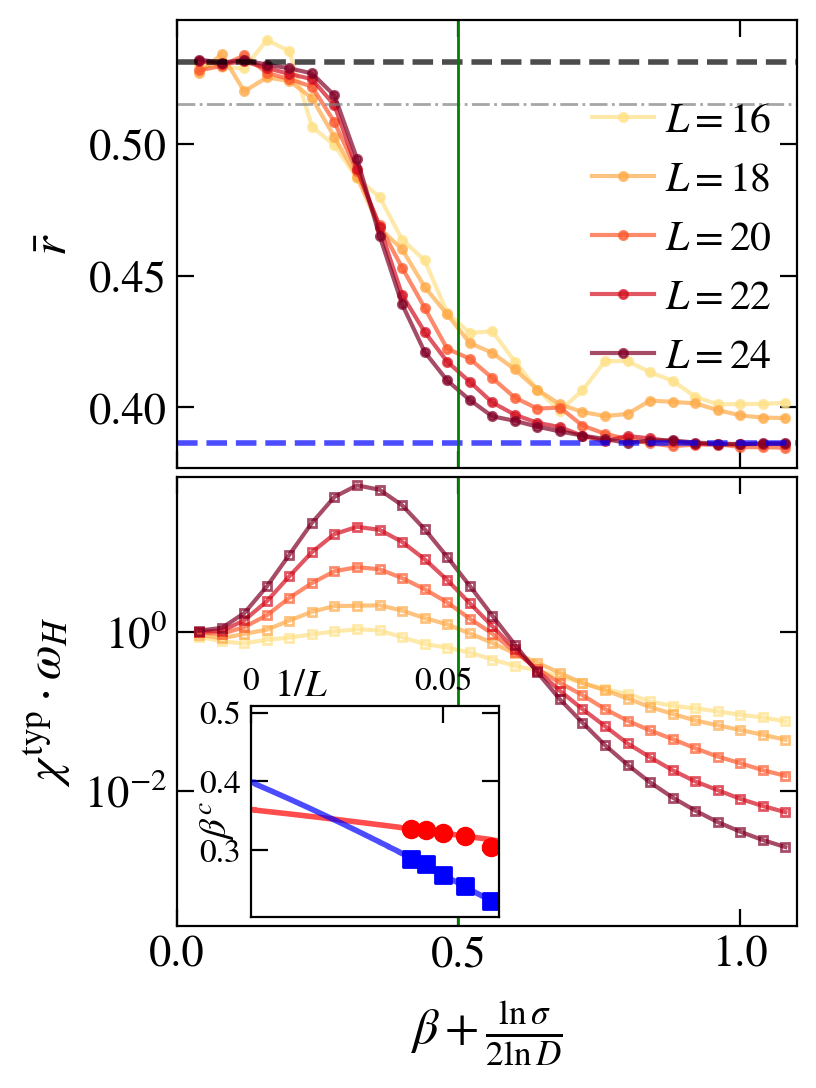

In [389]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
delta=0.55
op=0
hz=0

RESCALE = 0
BC = 0
use_gap_or_weight = 1

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'


sizes = np.arange(16, 25, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

dx_vals2 = np.arange(0.04, 1.11, 0.04)
    # dx_vals2 = np.arange(0.2, 0.66, 0.05)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_cut = 0.515 if use_gap_or_weight else 0.18

agp_max = np.zeros(sizes.shape)
r_drift = np.zeros(sizes.shape)
AGPs = []
for iiL, L in enumerate(sizes):
    real_sec, imag_sec = get_sectors(L, BC, hz)
    

    col = s_m.to_rgba(L)
    dx_vals = dx_vals2
    
    gap_ratio = np.zeros(dx_vals.shape)
    agp = np.zeros(dx_vals.shape)
    
    sigma_num = np.zeros(dx_vals.shape)
    for iid, dx in enumerate(dx_vals):
        
        dim_tot = 0
        # for [ks, ps, zxs] in [[0,1,1]]:
        for [ks, ps, zxs] in real_sec:
        # for [ks, ps, zxs] in real_sec+imag_sec:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))[0]
                    dim = Ex.size
                    dim_tot += factor * dim
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    
                    Eav = np.mean(Ex)
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                    # num = min([500, dim//10])
                    num = dim//2
                    
                    gap_ratio[iid] += np.mean(ratio_tmp) * factor * dim
                    
                    wH = np.mean(gaps[idx - num//2 : idx + num//2])
                    # agp[iid] += np.mean(file.get('susc_reg')[0,idx - num//2 : idx + num//2]) * wH * factor * dim
                    agp[iid] += np.exp( np.mean( np.log(file.get('susc')[0,idx - num//2 : idx + num//2]) )) * wH * factor * dim
                    
                    sigma_num[iid] += np.sqrt( np.mean( Ex**2 ) - np.mean( Ex )**2 ) * factor * dim
            else:
                print(name)
    
        agp[iid] /= dim_tot
        sigma_num[iid] /= dim_tot
        gap_ratio[iid] /= dim_tot
        
    gap_ratio = gap_ratio[~np.isinf(agp)]
    dx_vals = dx_vals[~np.isinf(agp)]
    agp = agp[~np.isinf(agp)]
    # print(L, agp)
    
    sigma = sigma_num#np.sqrt( (2 + delta**2 )/4 + dim**(-2*dx_vals) / 3) / 2 * np.sqrt(L)
    xx = binom(L, L//2)**(-dx_vals) if RESCALE else dx_vals# + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    
    axis[0].plot(xx, gap_ratio, color=col, marker='o', alpha=0.7, markersize=3, label=r"$L=%d$"%L)#, lw=0)
    axis[1].plot(xx, agp, color=col, markerfacecolor='None', marker='s', alpha=0.7, markersize=3)

    xx = dx_vals[dx_vals > 0.05]
    
    sigma = sigma_num[dx_vals > 0.05]#np.sqrt( (2 + delta**2 )/4 + dim**(-2*xx) / 3) / 2 * np.sqrt(L)
    # xx = xx + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    yy = agp[dx_vals > 0.05]
    AGPs.append(yy)
    
    indices = np.arange( max([np.argmax(yy) - 5, 0]), min([np.argmax(yy) + 7,xx.size]), 1)
    x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
    f = splrep(xx[indices], yy[indices], k=5, s=10)
    yy = splev(x, f)
    agp_max[iiL] = x[np.argmax(yy)]
    
    yy = gap_ratio[dx_vals > 0.05]
    idx = np.argmin(np.abs(yy - 0.515))
    indices = np.arange( max([idx - 5, 0]), min([idx + 10, xx.size]), 1)
    f = splrep(xx[indices], yy[indices], k=5, s=0)
    yy = splev(x, f)
    r_drift[iiL] = x[np.argmin(np.abs(yy - r_cut))]
    # axis[0].plot(x, yy, color=col, alpha=0.7)
    
# AGPs = np.array(AGPs)
# agp_cross = np.zeros( (sizes.size-1))    
# for iiL, L in enumerate(sizes[1:]):
#     xx = dx_vals[dx_vals > 0.1]
#     idx = np.argmin(np.abs(AGPs[iiL+1] - AGPs[iiL]))
#     indices = np.arange( max([idx - 10, 0]), min([idx + 7, xx.size]), 1)
#     x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
#     yy1 = AGPs[iiL]
#     yy2 = AGPs[iiL+1]
#     f = splrep(xx[indices], yy1[indices], k=5, s=0)
#     yy1 = splev(x, f)
#     f = splrep(xx[indices], yy2[indices], k=5, s=0)
#     yy2 = splev(x, f)
#     agp_cross[iiL] = x[np.argmin(np.abs(yy2 - yy1))]
 
fig_help.set_plot_elements(axis[0], ylabel=r"$\bar{r}$" if use_gap_or_weight else r"$\bar{q}$", xlabel=r"", font_size=16, set_legend=0, xscale='log' if RESCALE else 'linear', yscale='linear')
fig_help.set_plot_elements(axis[1], ylabel=r"$\chi^{\rm typ}\cdot\omega_H$", xlabel=r"$\Delta_2$" if RESCALE else r"$\beta+\frac{\ln\sigma}{2\ln{D}}$", font_size=16, set_legend=1, xscale='log' if RESCALE else 'linear', yscale='log')
if RESCALE: fig_help.set_legend(axis[0], fontsize=15, loc='upper left', anchor=(-0.02, 0.9))
else:       fig_help.set_legend(axis[0], fontsize=15, loc='upper right', anchor=(1.02, 0.9))

# axis[0].set_ylim(0.38, 0.54)
if not use_gap_or_weight: axis[0].set_ylim(0., 0.2)
axis[0].axhline(y=0.5308, ls='--', color='k', lw=2, alpha=0.7)
axis[0].axhline(y=2*np.log(2)-1, ls='--', color='blue', lw=2, alpha=0.7)
axis[0].axhline(y=r_cut, ls='-.', color='gray', lw=1, alpha=0.7)
axis[0].axvline(x=0.5, ls='-', color='green', lw=1)
axis[1].axvline(x=0.5, ls='-', color='green', lw=1)
axis[1].set_ylim(2e-4, 9e1)

if not RESCALE: 
    axis[0].set_xlim(0, 1.1)
else:
    z= np.logspace(-2, -0.25, 1000)
    axis[1].plot(z, 0.05/z**2, ls=':', color='pink')

inset = axis[1].inset_axes([0.12, 0.02, 0.4, 0.47])
# inset.scatter(1/sizes, agp_max, marker='o', color='red')
# inset.scatter(1/sizes, r_drift, marker='s', color='blue')
# inset.scatter(1/sizes[1:], agp_cross, marker='v', color='green')

def beta_c_fit(L, C, a):
    # return (np.log(2) - np.log(1/4**L * (C**2 * L + C * np.sqrt(L) * np.sqrt(4**(L+1) * a + C**2 * L)))) / (L * np.log(4))
    # return (np.log(2) - np.log(1/4**L * (C**2 * L**5 + C * np.sqrt(L**5) * np.sqrt(4**(L+1) * a + C**2 * L**5)))) / (L * np.log(4))
    # return 0.5 - C * np.exp(-a * L)
    return a + np.log(C) / (2*np.log( binom(L, L//2) ))# - np.log(np.sqrt( (2 + delta**2 )/4 + 2**(-2*L*xx) / 3) / 2 / 0.3413) / (2*np.log(binom(L, L//2)))
    # return 0.5 + np.log(C) / (2*np.log( binom(L, L//2) ))
    # return 0.5 + 1 / (2*L) - 1/2 * np.log(a * L) / (L * np.log(4))


LOG = 1
def plot_fit_inset(x, y, mar = 'o', col = 'red'):
    pars, pconv, fit_info, msg, _ = fit(beta_c_fit,
                        xdata = x[1:],
                        ydata = y[1:],
                        full_output=True, maxfev=10000)
    x_den = np.linspace(0, 1/(min(x)-1), 10000)
    # x_den = np.linspace(min(x)-1, max(x)+1, 10000)
    inset.scatter(1/x, y, marker=mar, color=col)
    inset.plot(x_den, beta_c_fit(1/x_den, *pars), color=col, ls='-', lw=2, alpha=0.7)
    # print(y, beta_c_fit(x, *pars))
    print(*pars)
    # inset.plot(x_den, )
plot_fit_inset(sizes, agp_max, mar='o', col='red')
plot_fit_inset(sizes, r_drift, mar='s', col='blue')
# inset.scatter(sizes[1:], agp_cross, marker='v', color='green')(1/sizes[1:], agp_cross, marker='v', color='green')

fig_help.set_plot_elements(inset, ylabel=r"$\beta^c$", xlabel=r"$1/L$", font_size=12, set_legend=True, xscale='linear', yscale='linear')
inset.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
inset.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))

inset.xaxis.set_label_coords(0.2, 1.05)
inset.yaxis.set_label_coords(-0.06, 0.46)

inset.set_xlim(0, 1/(min(sizes)-0.5))
# inset.set_xlim(min(sizes)-0.5, max(sizes)+0.5)
inset.set_ylim(None, 0.51)

inset.xaxis.set_ticks_position('top')
inset.xaxis.set_label_position('top')
# inset.yaxis.set_ticks_position('right')
# inset.yaxis.set_label_position('right')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=0,p=-1,zx=-1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=0,p=-1,zx=1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=0,p=1,zx=-1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=0,p=1,zx=1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=8,p=-1,zx=-1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=8,p=-1,zx=1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=8,p=1,zx=-1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=8,p=1,zx=1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Spectrals_SzSz2/_L=16,J1=1,J2=0,d1=0.55,d2=0.1,hz=0,k=1,zx=-1,Sz=0.0.hdf5
../results_fgr/symmetries/PBC/Sp

No handles with labels found to put in legend.
No handles with labels found to put in legend.


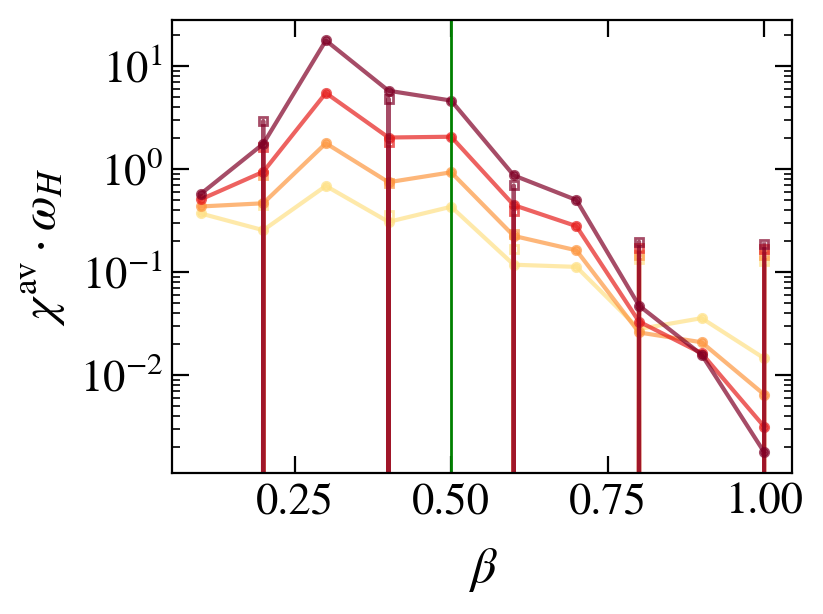

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
delta=0.55
op=0
hz=0

RESCALE = 0
BC = 0
use_gap_or_weight = 1

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
prefix2 = '../results_fgr/symmetries/OBC/Spectrals_SzSz2/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz2/'
# prefix = '../results_fgr/symmetries/OBC/energy_current/' if BC else '../results_fgr/symmetries/PBC/energy_current/'
# prefix2 = '../results_fgr/symmetries/OBC/energy_current/' if BC else '../results_fgr/symmetries/PBC/energy_current/'


sizes = np.arange(16, 23, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5

dx_vals2 = np.arange(0.04, 1.01, 0.04)
    # dx_vals2 = np.arange(0.2, 0.66, 0.05)

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

for iiL, L in enumerate(sizes):
    real_sec, imag_sec = get_sectors(L, BC, hz)

    col = s_m.to_rgba(L)
    dx_vals = dx_vals2
    agp = np.zeros(dx_vals.shape)
    agp_br = np.zeros(dx_vals.shape)
    
    sigma_num = np.zeros(dx_vals.shape)
    for iid, dx in enumerate(dx_vals):
        
        dim_tot = 0
        # for [ks, ps, zxs] in [[0,1,1]]:
        # for [ks, ps, zxs] in real_sec:
        for [ks, ps, zxs] in real_sec+imag_sec:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))[0]
                    dim = Ex.size
                    dim_tot += factor * dim
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    
                    Eav = np.mean(Ex)
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                    # num = min([500, dim//10])
                    num = dim//2
                    
                    wH = np.mean(gaps[idx - num//2 : idx + num//2])
                    agp[iid] += np.mean(file.get('susc_reg')[0,idx - num//2 : idx + num//2]) * wH * factor * dim
                    # agp[iid] += np.exp( np.mean( np.log(file.get('susc')[0,idx - num//2 : idx + num//2]) )) * wH * factor * dim
            else:
                print(name)
                
            name = prefix2 + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))[0]
                    dim = Ex.size
                    dim_tot += factor * dim
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    
                    Eav = np.mean(Ex)
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                    # num = min([500, dim//10])
                    num = dim//2
                    
                    wH = np.mean(gaps[idx - num//2 : idx + num//2])
                    agp_br[iid] += np.mean(file.get('susc_reg')[0,idx - num//2 : idx + num//2]) * wH * factor * dim
                    # agp[iid] += np.exp( np.mean( np.log(file.get('susc')[0,idx - num//2 : idx + num//2]) )) * wH * factor * dim
            else:
                print(name)
    
        agp[iid] /= dim_tot
        agp_br[iid] /= dim_tot
        
    dx_vals = dx_vals[~np.isinf(agp)]
    agp_br = agp_br[~np.isinf(agp)]
    agp = agp[~np.isinf(agp)]
    
    axis.plot(dx_vals, agp, color=col, marker='o', alpha=0.7, markersize=3)
    axis.plot(dx_vals, agp_br, color=col, markerfacecolor='None', marker='s', alpha=0.7, markersize=3)

 
fig_help.set_plot_elements(axis, ylabel=r"$\chi^{\rm av}\cdot\omega_H$", xlabel=r"$\Delta_2$" if RESCALE else r"$\beta$", font_size=16, set_legend=1, xscale='log' if RESCALE else 'linear', yscale='log')
fig_help.set_legend(axis, fontsize=15, loc='lower left')

axis.axvline(x=0.5, ls='-', color='green', lw=1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

0.15000000000000002
0.2
0.25
0.30000000000000004
0.35000000000000003
0.4
0.45
0.5
0.55
0.6000000000000001
0.65
0.7000000000000001
0.75
0.8


No handles with labels found to put in legend.


0.8500000000000001
[0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8
 0.85]
[0.02, 0.18110110110110111, 0.2269069069069069, 0.2603203203203203, 0.2722922922922923, 0.2910910910910911, 0.3040840840840841, 0.31689689689689693, 0.3211011011011011, 0.3207007007007007, 0.3146946946946947, 0.3007007007007007, 0.2819019019019019, 0.2565165165165165, 0.2034834834834835]


(0.05, 0.95)

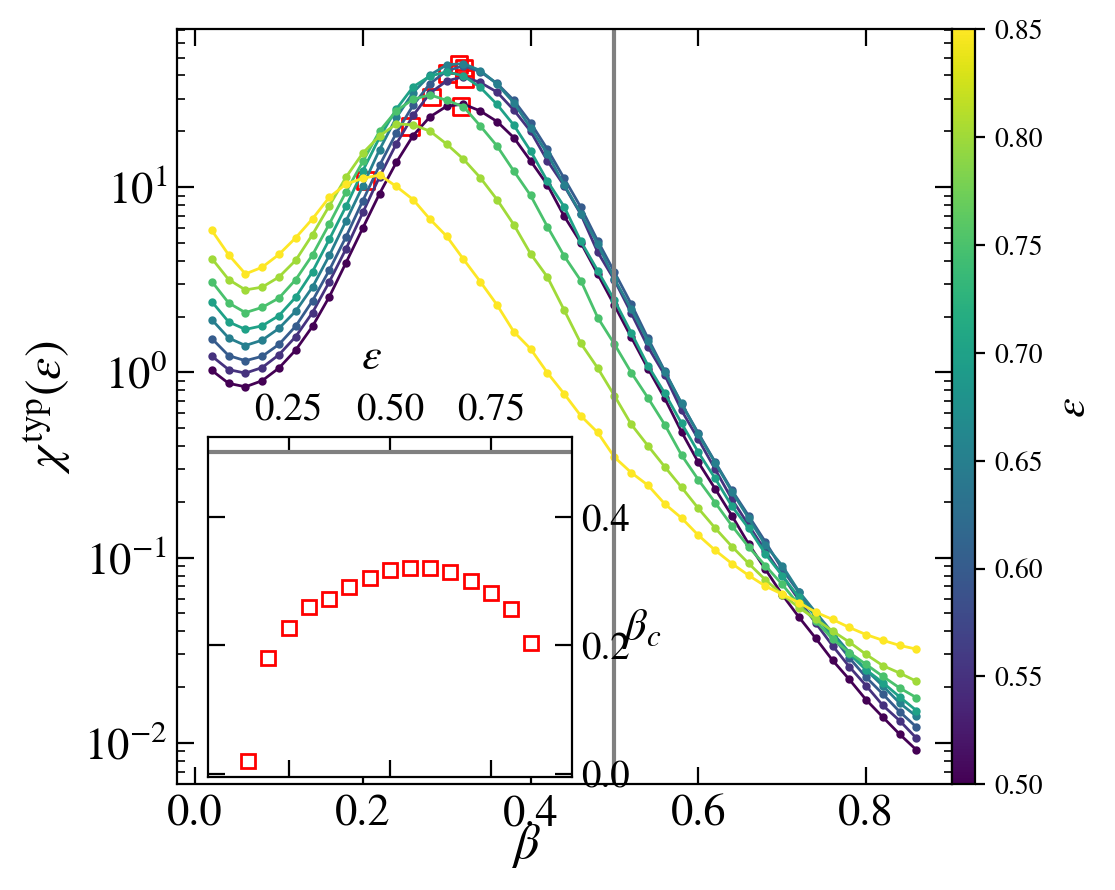

In [199]:

L = 22
w = 2
J = 1
delta=0.55
op=0

BC = 0

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(16, 23, 2)

dx_vals2 = np.arange(0.02, 0.87, 0.02)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

inset = axis.inset_axes([0.04, 0.01, 0.47, 0.45])

depsilon = 0.5
_eps_ = np.arange(0.0, 1.01, 0.05)
_eps_ = _eps_[_eps_ <= 0.88]
_eps_ = _eps_[_eps_ >= 0.15]

s_m_a = matplotlib.cm.ScalarMappable(cmap='coolwarm', norm= matplotlib.colors.Normalize(vmin=min(dx_vals2), vmax=max(dx_vals2) ))
# s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=min(_eps_), vmax=0.5 ))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm= matplotlib.colors.Normalize(vmin=0.5, vmax=max(_eps_) ))
s_m.set_array([])

alfa_c = []
alfa_c2 = []
agp_c = []
for jj in range(_eps_.size):
    eps = _eps_[jj]
    col2 = s_m.to_rgba(eps)
    # print(eps)
    agp      = np.zeros((dx_vals2.size));
    
    real_sec, imag_sec = get_sectors(L, BC, hz)
    
    for ii, dx in enumerate(dx_vals2):
        alfa = np.round(dx, 2)
        col = s_m_a.to_rgba(alfa)
        
        dim_tot = 0
        # for [ks, ps, zxs] in [[0,1,1]]:
        # for [ks, ps, zxs] in real_sec:
        for [ks, ps, zxs] in real_sec+imag_sec:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))[0]
                    dim = Ex.size
                    dim_tot += factor * dim
                    
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    
                    Eav1 = Ex[0] + eps * (Ex[-1] - Ex[0]) - depsilon
                    idx1 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav1))
                    if idx1 < 0: idx1=1
                    
                    Eav2 = Ex[0] + eps * (Ex[-1] - Ex[0]) + depsilon
                    idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav2))
                    if idx2 >= dim: idx2=dim-2
                    
                    wH = np.mean(gaps[idx1 : idx2])
                    # print(wH)
                    # agp[ii] += np.mean(file.get('susc_reg')[0,idx1 : idx2]) * wH * factor * dim
                    agp[ii] += np.exp( np.mean( np.log(file.get('susc')[0,idx1 : idx2]) )) * wH * factor * dim
            else:
                print(name)
        
        agp[ii] /= dim_tot
    
    print(eps)
    norm = dim#max(agp2)#matelem**2 / wH**2
    if eps >= 0.5:
        axis.plot(dx_vals2, agp, color=col2, marker='o', markersize=2, lw=1)
    
    idx = np.argmax(agp)
    
    # agp = agp[dx_vals2>0.1]
    x = dx_vals2#[dx_vals2>0.1]
    indices = np.arange(max(np.argmax(agp) - 5,0), min(np.argmax(agp) + 6, agp.size-1), 1)
    x = np.linspace(x[indices][0], x[indices][-1], 1000)
    f = splrep(dx_vals2[indices], agp[indices], k=3, s=5)
    agp = splev(x, f)
    idx = np.argmax(agp)
    alfa_c.append(x[idx])
    if eps >= 0.5:
        alfa_c2.append(x[idx])
        agp_c.append(agp[idx])
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, alpha=0.5)
    
    # if eps <= 0.5:
    #     axis.plot(x, agp, color=col2, lw=4, alpha=0.35)
print(_eps_)
print(alfa_c)
inset.plot(_eps_, alfa_c,  marker='s', color='red', ls='--', markersize=5, lw=0, markerfacecolor='None')#, label=r"$L=%d$"%(L))
# z = np.linspace(0, 1, 1000)
# inset.plot(z, 2 - 8 * (z - 0.5)**2, ls='--', color='k')
# a = 1.05
# b = 0.45
# alfac = g_crit#1 / np.sqrt(2)
# x = np.linspace(0.13, 0.87, 1000)
# inset.plot(x, alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), color='k', ls='--', lw=2, label=r"$L=\infty$")
axis.scatter(alfa_c2, agp_c, marker='s', color='red', facecolor='None')

axis.xaxis.set_label_coords(.45, -0.05)

axis.axvline(x=0.5, ls='-', c='gray')
# axis.axvline(x=alfa_crit,    ls=':', c='k')
# axis.set_xlim(0, 1)
ylab = r"$\chi^{\rm typ}(\epsilon)$"
fig_help.set_plot_elements(axis, ylabel=ylab, xlabel=r"$\beta$", font_size=16, set_legend=False, xscale='linear', yscale='log')
# axis.set_ylim(5e-8, None)


cbar_ax = axis.inset_axes([1., 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\epsilon$", fontsize=16)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')

inset.xaxis.set_label_position("top")
inset.xaxis.set_label_coords(.45, 1.2)
inset.xaxis.tick_top()

inset.yaxis.set_label_position("right")
# inset.yaxis.set_label_coords(1.24, 0.59)
inset.yaxis.tick_right()
fig_help.set_plot_elements(inset, ylabel=r"$\beta_c^*$", xlabel=r"$\epsilon$", font_size=14, set_legend=False, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=12, loc='lower center')

# inset.set_yticks([1, 1.2, 1.4, 1.6, 1.8, 2.0])

inset.set_ylabel(r"$\beta_c$", rotation=0, fontsize=16)

inset.axhline(y=0.5,    ls='-', color='gray')
# inset.axhline(y=2, ls='-', color='gray')
# inset.set_ylim(0.0, 2.05)
inset.set_xlim(0.05, 0.95)

# fig.savefig("PLOTS_FADING/Fig_max_chaos_mobility.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


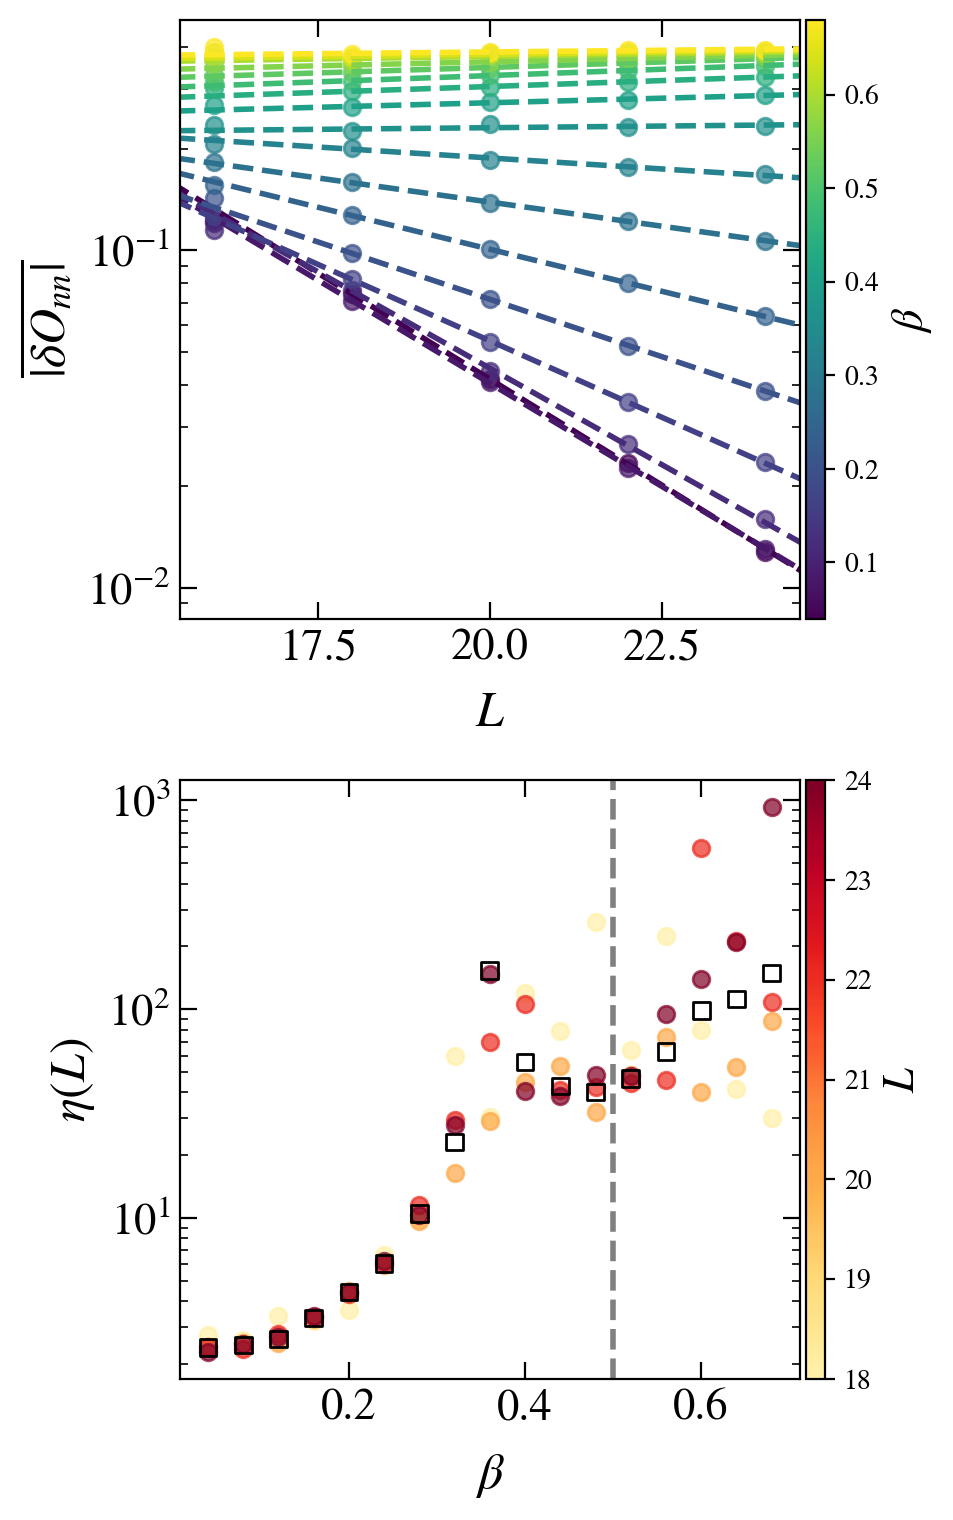

In [384]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

BC = 0

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(16, 25, 2)

DIM = 1
fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)


r_idx = 5
corr = 0
gx = 1.5
window = 40

L = 15
eps = 0.5

def exp_fit_kurwa(x, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * 2**(-x * xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

dx_vals = np.arange(0.04, 0.71, 0.04)

# dx_vals = np.arange(0.36, 0.61, 0.02)

norm = matplotlib.colors.Normalize(
        vmin=min(dx_vals),
        vmax=max(dx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, dx in enumerate(dx_vals):
    col = s_m.to_rgba(dx)
    
    e_to_e_fluct = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        real_sec, imag_sec = get_sectors(L, BC, hz)
        dim_tot = 0
        # for [ks, ps, zxs] in [[0,1,1]]:
        for [ks, ps, zxs] in real_sec:
        # for [ks, ps, zxs] in real_sec + imag_sec:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies'))[0]
                    dim = Ex.size
                    dim_tot += factor * dim
                    
                    Eav = np.mean(Ex)
                    idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                    num = dim//2
                    # num = min([500, dim//10])
                    
                    z = np.abs(np.diff(np.array(file.get('diag_mat'))[0]))
                    # print( np.mean(z ))
                    e_to_e_fluct[iiL] += np.mean(z[idx - num//2 : idx + num//2]) * factor * dim
                    # e_to_e_fluct[iiL] += np.mean(z) * factor * dim
            else:
                print(name)
        # print(L, e_to_e_fluct)    
        e_to_e_fluct[iiL] /= dim_tot
    # print(L, e_to_e_fluct)
    yy = e_to_e_fluct
    # print(gx, sizes, yy)
    parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
                    xdata = sizes[1:],
                    ydata = yy[1:],
                    full_output=True, maxfev=10000)
    A = parsolo[0]
    eta_fit = 1 / parsolo[1]
    if eta_fit > 1e6:
        eta_fit = np.nan
    etas_fit.append(eta_fit)
    # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
    axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].scatter(sizes, yy, color=col, alpha=0.7)
    
    eta = 1 / (np.diff( np.log(e_to_e_fluct) ) / np.diff(sizes) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$\beta$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)


s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
for iiL, L in enumerate(sizes[1:]):
    col = s_m.to_rgba(L)
    # axis[1].scatter(2**(-L*dx_vals), np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  
    axis[1].scatter(dx_vals, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

axis[1].scatter(dx_vals, np.abs(etas_fit), color='k', marker='s', facecolor='None')


axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

axis[1].axvline(x=0.5, ls='--', color='gray', lw=2)
# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$\overline{|\delta O_{nn}|}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$\beta$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

0.02 [0.57492871 0.5099894  0.5349584  0.53781945 0.53061775 0.52855545
 0.5363193  0.53147359 0.52696851 0.53272838 0.53220698 0.52865713
 0.53374721 0.5298156  0.53871439 0.53414879 0.52402331 0.54056227]
0.04 [0.49971433 0.5365278  0.53540484 0.52777101 0.53112858 0.5329006
 0.52731466 0.53119362 0.53190997 0.53089823 0.53275118 0.52501099
 0.53534255 0.52992161 0.53384723 0.5230346  0.5227931  0.51108969]
0.06 [0.47854763 0.52583815 0.5356381  0.53140305 0.52789071 0.53395627
 0.52535676 0.5322468  0.53466972 0.53191951 0.53481429 0.53590769
 0.53580403 0.53014285 0.52538721 0.53686499 0.53366128 0.51605689]
0.08 [0.49638141 0.53460298 0.53098231 0.52786991 0.53520598 0.53172849
 0.52503337 0.53230148 0.53129686 0.53031175 0.53285656 0.5283196
 0.5269215  0.52656974 0.53719616 0.53050746 0.52585003 0.48229704]
0.1 [0.48756494 0.49719719 0.53475988 0.53706424 0.52648291 0.5331473
 0.53246135 0.52693072 0.53478544 0.5319364  0.53121787 0.52882825
 0.53038313 0.54000908 0.52372353 0.5

Text(0.5, 1.0, '$\\langle r\\rangle$')

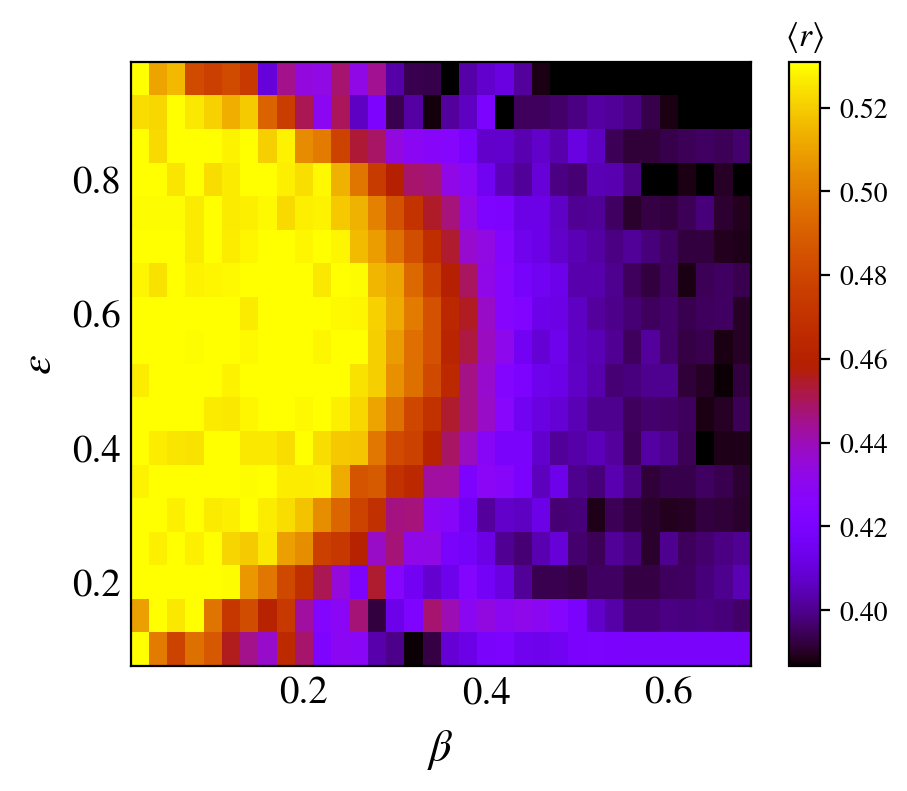

In [101]:

markers = itertools.cycle(markers_ls)


L = 22
w = 2
J = 1
delta=0.55
op=0

BC = 0

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(12, 18, 2)

dx_vals2 = np.arange(0.02, 0.69, 0.02)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

depsilon = 0.1
energy_density = np.arange(0.1, 0.99, 0.05)
gap_ratio_density = []
for ii, dx in enumerate(dx_vals2):
    dim_tot = 0
    gaps_dens_eps = np.zeros(energy_density.shape)
    
    # for [ks, ps, zxs] in [[0,1,1]]:
    # for [ks, ps, zxs] in imag_sec:
    for [ks, ps, zxs] in real_sec+imag_sec:
        factor = 1 if ks == 0 or ks == L / 2 else 2
        name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies'))[0]
                dim = Ex.size
                dim_tot += factor * dim
                gaps = np.diff(Ex)
                ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                
                for iie, eps in enumerate(energy_density):
                    Eav1 = Ex[0] + eps * (Ex[-1] - Ex[0]) - depsilon
                    idx1 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav1))
                    if idx1 < 0: idx1=1
                    
                    Eav2 = Ex[0] + eps * (Ex[-1] - Ex[0]) + depsilon
                    idx2 = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav2))
                    if idx2 >= dim: idx2=dim-2
                    
                    gaps_dens_eps[iie] += np.mean(ratio_tmp[idx1: idx2]) * factor * dim
        else:
            print(name)
    
    gaps_dens_eps = gaps_dens_eps / dim_tot
    print(dx, gaps_dens_eps)
    gap_ratio_density.append(gaps_dens_eps)

gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([dx_vals2 for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(dx_vals2, energy_density)

print(X.shape, Y.shape, gap_ratio_density.shape)
p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867, vmax=0.5309, rasterized=True)
# p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest')
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$\beta$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)

clb = fig.colorbar(p)
clb.solids.set_edgecolor("face")     # avoid white gridlines
clb.solids.set_rasterized(True)
clb.ax.set_title(r"$\langle r\rangle$" if use_gap_or_weight else r"$1-\langle q\rangle$")

# a = 1.05
# b = 0.45
# alfac = alfa_crit
# alfac = 1 / np.sqrt(2)
# x = np.linspace(0.04, 0.96, 1000)
# axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='k', ls='-', lw=2, label=r"Eq. (B1)", rasterized=True)
# leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', anchor=(0.0, 0.96), ncol=2)
# leg.set_rasterized(True)
# axis.set_ylim(0.05, 0.94)

# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# fig.savefig("plots_AGP/FigS2.png", bbox_inches = 'tight', pad_inches=0.02)
# from PIL import Image
# fname = 'plots_AGP/FigS2.png'
# image = Image.open(fname).convert("L")
# arr = np.asarray(image)
# figura, ax_gray = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex=True)
# ax_gray.set_axis_off()
# ax_gray.imshow(arr, cmap='gray', vmin=0, vmax=255)



No handles with labels found to put in legend.


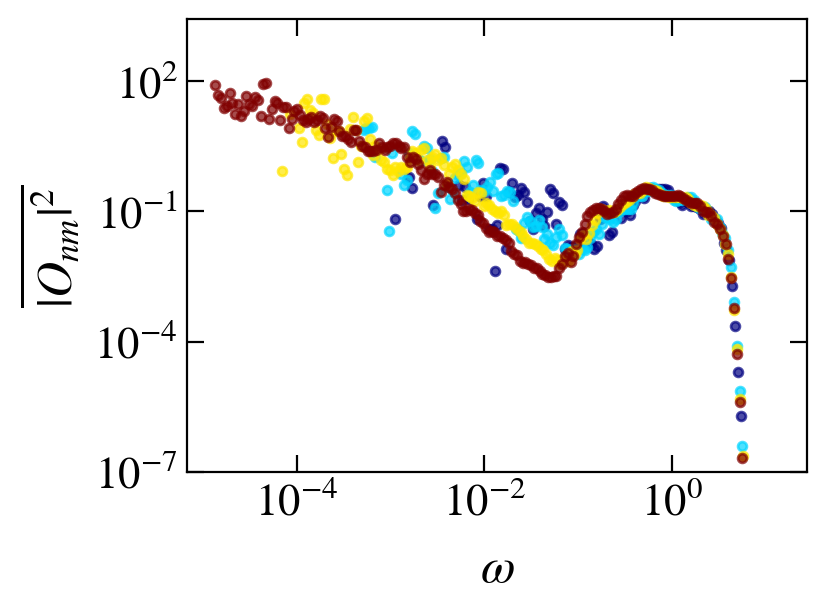

In [202]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0


INTEGRATED = 0
BC = 0

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(16, 23, 2)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 15
eps = 0.5


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])


dx = 0.5
for iiL, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    
    omega_num = 10*L - 1
    omegas = np.zeros((omega_num))
    spec_fun = np.zeros((omega_num))
    element_count = np.zeros((omega_num))
    dim_tot = 0
    real_sec, imag_sec = get_sectors(L, BC, hz)
    # for [ks, ps, zxs] in [[0,1,1]]:
    for [ks, ps, zxs] in imag_sec + real_sec:
    # for [ks, ps, zxs] in real_sec:
        factor = 1 if ks == 0 or ks == L / 2 else 2
        name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))[0]
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                En = np.array(file.get('energies'))[0]
                dim = En.size
                dim_tot += dim * factor
                
                wH =  np.array(file.get('wH'))[0]
                spec = np.array(file.get('spectral_fun'))[idx] * factor * dim
                element_count += np.array(file.get('element_count'))[idx] * factor * dim
                
                int_spec_fun = np.array(file.get('integrated_spectral_fun'))[idx]
                int_spec_fun = (int_spec_fun - int_spec_fun[0]) / (int_spec_fun[-1] - int_spec_fun[0])
                
                if INTEGRATED:  spec_fun += int_spec_fun * factor * dim
                else: spec_fun += spec / wH
                omegas = np.array(file.get('omegas'))[0,1:]
        else:
            print(name)
    if INTEGRATED: 
        spec_fun /= dim_tot
    else:
        spec_fun /= element_count
    # print(spec_fun.shape, omegas.shape)
    omegas = (omegas[1:] + omegas[:-1]) / 2# * L**2
    spec_fun = (spec_fun[1:] + spec_fun[:-1]) / 2
    axis.scatter(omegas, spec_fun, color=col, alpha=0.7, s=10)
    
    
fig_help.set_plot_elements(axis, ylabel=r"$\overline{|O_{nm}|^2}$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='log' if INTEGRATED else 'log')

# z = np.logspace(-3, 1, 1000)
# # axis.plot(z, 0.02/z, ls=':', color='k', lw=2)
# axis.plot(z, 2e0/z**2, ls='--', color='k', lw=2)
# axis.plot(z, 200*z**2, ls='-.', color='red', lw=2)

if INTEGRATED:  axis.set_ylim(0,1)
else:           axis.set_ylim(1e-7, None)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


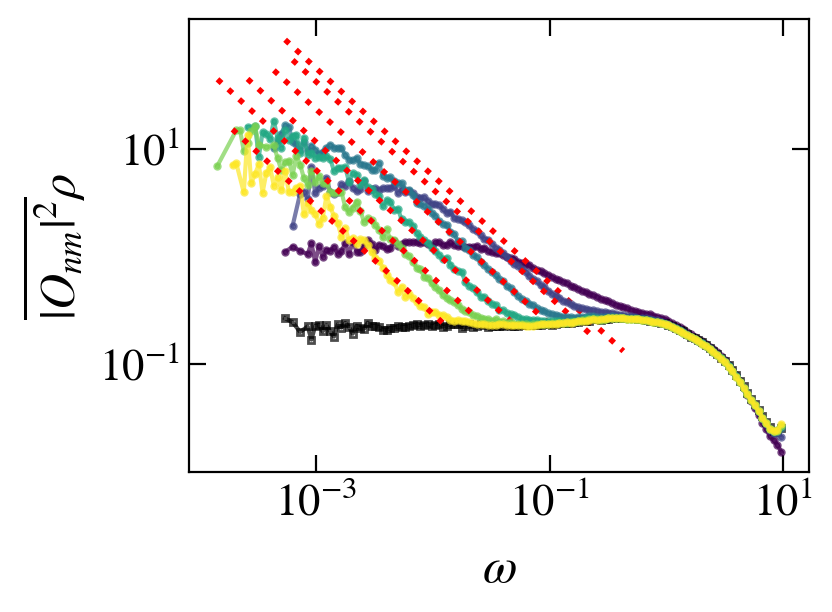

In [437]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 22
w = 2
J = 1
g=0.2
op=0


INTEGRATED = 0
BC = 0

# prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
prefix = '../results_fgr/symmetries/OBC/energy_current/' if BC else '../results_fgr/symmetries/PBC/energy_current/'
hz = 0

sizes = np.arange(16, 23, 2)
dx_vals = np.arange(0.1, 0.61, 0.1)

DIM = 1
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200, sharex=True, sharey=False)

L = 18
eps = 0.5


norm = matplotlib.colors.Normalize(
        vmin=min(dx_vals),
        vmax=max(dx_vals))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])


dx = 0.2
for iiL, dx in enumerate(dx_vals):
    col = s_m.to_rgba(dx)

    omega_num = 10*L - 1
    omegas = np.zeros((omega_num))
    spec_fun = np.zeros((omega_num))
    spec_fun0 = np.zeros((omega_num))
    element_count0 = np.zeros((omega_num))
    element_count = np.zeros((omega_num))
    dim_tot = 0
    real_sec, imag_sec = get_sectors(L, BC, hz)
    # for [ks, ps, zxs] in [[1,1,1]]:
    for [ks, ps, zxs] in imag_sec:# + real_sec:
    # for [ks, ps, zxs] in real_sec:
        factor = 1 if ks == 0 or ks == L / 2 else 2
        name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energy_density'))[0]
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                
                En = np.array(file.get('energies'))[0]
                dim = En.size
                dim_tot += dim * factor
                
                dE = En[-1] - En[0]
                # wH =  np.array(file.get('wH'))[0]
                wH = np.zeros((Ex.size-1))
                for iie, eps in enumerate(Ex[:-1]):
                    Eav1 = En[0] + Ex[iie] * dE
                    idx1 = min(range(len(En)), key=lambda i: abs(En[i] - Eav1))
                    if idx1 < 0: idx1=1
                    
                    Eav2 = En[0] + Ex[iie+1] * dE
                    idx2 = min(range(len(En)), key=lambda i: abs(En[i] - Eav2))
                    if idx2 >= dim: idx2=dim-2
                    
                    # print(L, Ex[iie], idx1, idx2)
                    wH[iie] = np.mean(gaps[idx1 : idx2])
                
                # print(wH)
                DOS = 1/wH
                if INTEGRATED:
                    spec = np.array(file.get('integrated_spectral_fun'))[idx]
                    spec0 = np.array(file.get('integrated_spectral_fun0'))[idx]
                    spec = spec - spec0
                    spec = (spec - spec[0]) / (spec[-1] - spec[0])
                    spec_fun += spec * factor * dim
                    # spec_fun0 += spec0 / wH * factor * dim
                else:
                    # spec = np.array(file.get('spectral_fun'))[idx]
                    # spec0 = np.array(file.get('spectral_fun0'))[idx]
                    # element_count = np.array(file.get('element_count'))[idx]
                    # element_count0 = np.array(file.get('element_count0'))[idx]
                    # spec = np.zeros((omega_num))
                    # element_count = np.zeros((omega_num))
                    # spec0 = np.zeros((omega_num))
                    # element_count0 = np.zeros((omega_num))
                    # for ii in range(Ex.size-1):
                    #     _grh_ = np.array(file.get('spectral_fun'))[ii]
                    #     _grh_elem = np.array(file.get('element_count'))[ii]
                    #     indices = np.argwhere(_grh_elem > 0)
                    #     spec_fun[indices] += _grh_[indices] * DOS[ii]
                    #     element_count[indices] += _grh_elem[indices]
                        
                    #     _grh_ = np.array(file.get('spectral_fun0'))[ii]
                    #     _grh_elem = np.array(file.get('element_count0'))[ii]
                    #     indices = np.argwhere(_grh_elem > 0)
                    #     spec_fun0[indices] += _grh_[indices] * DOS[ii]
                    #     element_count0[indices] += _grh_elem[indices]
                    
                    spec = np.array(file.get('spectral_fun_all'))[0]
                    spec0 = np.array(file.get('spectral_fun_all0'))[0]
                    element_count = np.array(file.get('element_count_all'))[0]
                    element_count0 = np.array(file.get('element_count_all0'))[0]

                    spec_fun += spec / element_count * dim * factor * dim
                    spec_fun0 += spec0 / element_count0 * dim * factor * dim
                omegas = np.array(file.get('omegas'))[0, 1:]
        else:
            print(name)
    spec_fun /= dim_tot
    spec_fun0 /= dim_tot

    spec_fun0 = spec_fun0[~np.isnan(spec_fun)]
    omegas = omegas[~np.isnan(spec_fun)]
    spec_fun = spec_fun[~np.isnan(spec_fun)]

    omegas = omegas[~np.isnan(spec_fun0)]
    spec_fun = spec_fun[~np.isnan(spec_fun0)]
    spec_fun0 = spec_fun0[~np.isnan(spec_fun0)]

    # num_av = 2
    # end_idx = int(spec_fun.size / float(num_av)) * num_av
    # x = np.zeros( (spec_fun[:end_idx:num_av].size) )
    # y = np.zeros( (spec_fun[:end_idx:num_av].size) )
    # z = np.zeros( (spec_fun[:end_idx:num_av].size) )
    # w = np.zeros( (spec_fun[:end_idx:num_av].size) )
    # for ijk in range(num_av):
    #     x += spec_fun[ijk:end_idx:num_av]
    #     y += spec_fun0[ijk:end_idx:num_av]
    #     w += omegas[ijk:end_idx:num_av]
    # spec_fun = x / num_av
    # spec_fun0 = y / num_av
    # omegas = w / num_av

    g = 2**(-dx * L)
    axis.plot(omegas, spec_fun, color=col, marker='o', alpha=0.7, markersize=2)
    if iiL==0: axis.plot(omegas, spec_fun0, color='k', marker='s', alpha=0.7, markersize=2, markerfacecolor='None')
    
    if dx > 0.0:
        idx = np.argmin(np.abs( np.log10(spec_fun / spec_fun0)[:-10] - 0.1))
        # axis.axvline(x=omegas[idx], color=col)
        z = np.logspace(np.log10(omegas[0]), np.log10(omegas[idx]), 1000)
        idx_z = np.argmin(np.abs(z - omegas[idx//4 * 3]))
        axis.plot(z, 1/z**1 * spec_fun[idx//4 * 3] * z[idx_z]**1, ls=':', color='red', lw=2)
    
fig_help.set_plot_elements(axis, ylabel=r"$\overline{|O_{nm}|^2}\rho$", xlabel=r"$\omega$", font_size=16, set_legend=1, xscale='log', yscale='linear' if INTEGRATED else 'log')


# axis.plot(z, 5e-2/z**2, ls='--', color='k', lw=2, alpha=0.7)
# axis.plot(z, 200*z**2, ls='-.', color='red', lw=2)
# axis.set_ylim(1e-7, 7e1)

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.


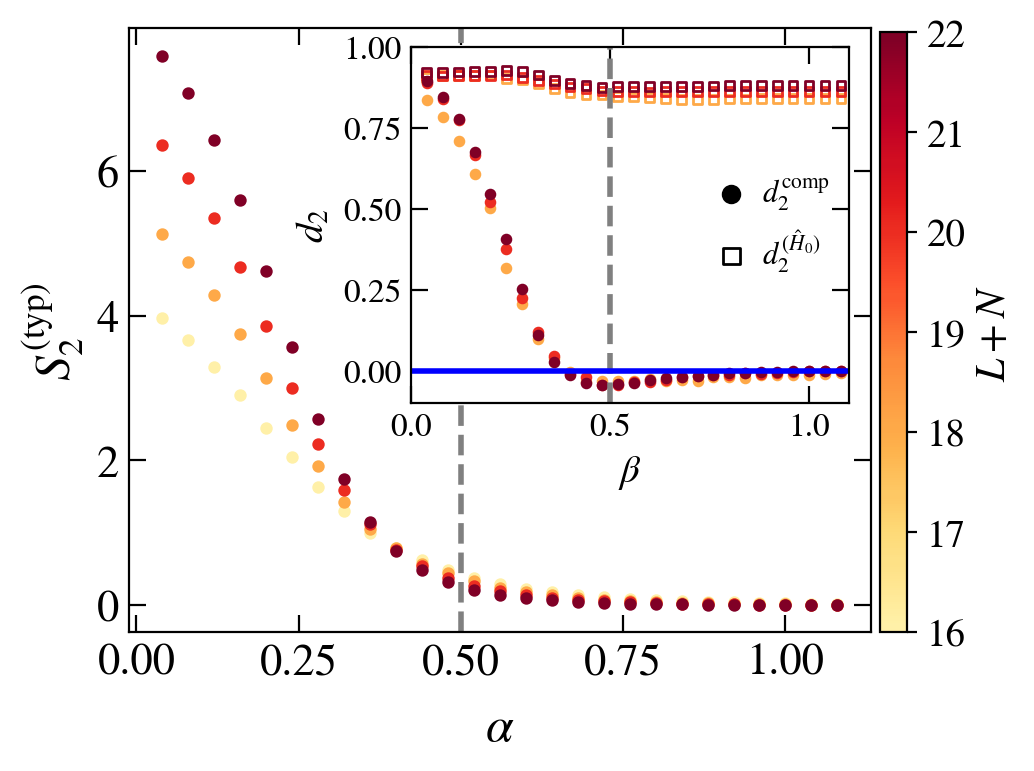

In [441]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0


INTEGRATED = 0
BC = 0

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(16, 23, 2)
dx_vals = np.arange(0.04, 1.09, 0.04)
dx_crit = 0.5


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5, 4), dpi = 200, sharex=True)
inset = axis.inset_axes([0.38, 0.38, 0.59, 0.59])

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

iddx = -2
qs = [0.5, 1.0, 1.5, 2, 3.0]
q = qs[iddx]

pr_all = []
Sinfo_all = []
pr_comp_all = []
Sinfo_comp_all = []
for L in sizes:
    col = s_m.to_rgba(L)
    
    pr       = np.zeros((dx_vals.size))
    Sinfo    = np.zeros((dx_vals.size))
    pr_comp       = np.zeros((dx_vals.size))
    Sinfo_comp    = np.zeros((dx_vals.size))
    real_sec, imag_sec = get_sectors(L, BC, hz)
    
    for ii, dx in enumerate(dx_vals):
        dim_tot = 0
        for [ks, ps, zxs] in real_sec + imag_sec:
        # for [ks, ps, zxs] in real_sec:
        # for [ks, ps, zxs] in [[0,1,1]]:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    E = np.array(file.get('energies'))[0]
                    dim = E.size
                    
                    dim_tot += factor * dim
                    Etarget = np.mean(E)#E[0] + 0.2 * (E[-1] - E[0])
                    
                    idxE = np.argmin(np.abs(E - Etarget))
                    num = int( min(500, 0.1*dim) )
                    # num = dim//2
                    
                    idx_min = idxE - num//2
                    if idx_min < 0: idx_min = 0
                    idx_max = idxE + num//2
                    if idx_max > dim-1: idx_max = dim
                    
                    # print(idxE, idxE - num//2, idxE + num//2)
                    # pr[ii] = np.mean(np.array(file.get('Pr_q'))[iddx])
                    _pr_ = np.array(file.get('Pr'))[0, idx_min : idx_max]
                    _pr_comp_ = np.array(file.get('Pr_comp'))[0, idx_min : idx_max]
                    
                    pr[ii] += np.mean(_pr_) * factor * dim
                    pr_comp[ii] += np.mean(_pr_comp_) * factor * dim
                    Sinfo[ii] += -np.mean(np.log(_pr_)) * factor * dim
                    Sinfo_comp[ii] += -np.mean(np.log(_pr_comp_)) * factor * dim
                    
            else:
                print(name)
        pr[ii] /= dim_tot
        pr_comp[ii] /= dim_tot
        Sinfo[ii] /= dim_tot
        Sinfo_comp[ii] /= dim_tot
    # print(L, Sinfo)
    axis.scatter(dx_vals, Sinfo, color=col, s=12)
    pr_all.append(pr)
    Sinfo_all.append(Sinfo)
    pr_comp_all.append(pr_comp)
    Sinfo_comp_all.append(Sinfo_comp)

pr_all = np.transpose(np.array(pr_all))
Sinfo_all = np.transpose(np.array(Sinfo_all))
pr_comp_all = np.transpose(np.array(pr_comp_all))
Sinfo_comp_all = np.transpose(np.array(Sinfo_comp_all))

d2 = np.zeros( (dx_vals.size, sizes.size-1) )
d2_comp = np.zeros( (dx_vals.size, sizes.size-1) )

def _fun_pr(L, a, d2):
    return a * 2**(-d2 * L)

def _fun_info(L, a, d2):
    return d2 * L + a


for ii, dx in enumerate(dx_vals):
    _info_comp_ = Sinfo_comp_all[ii]
    _info_      = Sinfo_all[ii]
    
    a = np.diff(_info_) / np.diff(sizes)
    # a = (a[1:] + a[:-1])/2
    d2[ii] = a / np.log(2)
    
    
    a = np.diff(_info_comp_) / np.diff(sizes)
    # a = (a[1:] + a[:-1])/2
    d2_comp[ii] = a / np.log(2)
    
    # _pr_comp_ = pr_comp_all[ii]
    # _pr_      = pr_all[ii]
    
    # a = -np.diff(_pr_) / np.diff(2**sizes)
    # # a = (a[1:] + a[:-1])/2
    # d2[ii] = a / np.log(2)
    
    
    # a = -np.diff(_pr_comp_) / np.diff(2**sizes)
    # # a = (a[1:] + a[:-1])/2
    # d2_comp[ii] = a / np.log(2)

d2 = np.transpose(np.array(d2))
d2_comp = np.transpose(np.array(d2_comp))

for iiL, L_total in enumerate( sizes[1:] ):
    col = s_m.to_rgba(L_total)
    inset.scatter(dx_vals, d2[iiL], color=col, s=10)
    inset.scatter(dx_vals, d2_comp[iiL], color=col, marker='s', facecolor='None', s=10)
        
        
inset.scatter(np.nan, np.nan, color='k', label=r"$d_2^{\rm comp}$")  
inset.scatter(np.nan, np.nan, color='k', label=r"$d_2^{(\hat{H}_0)}$", marker='s', facecolor='None')

axis.axvline(x=dx_crit, ls='--', color='gray', lw=2)
inset.axvline(x=dx_crit, ls='--', color='gray', lw=2)
inset.axhline(y=0, ls='-', color='blue', lw=2)

# inset.xaxis.set_ticks_position('top')
# inset.xaxis.set_label_position('top')
# inset.yaxis.set_ticks_position('right')
# inset.yaxis.set_label_position('right')

fig_help.set_plot_elements(axis, ylabel=r"$S_2^{\rm (typ)}$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# axis.set_ylim(0, 6÷)

fig_help.set_plot_elements(inset, ylabel=r"$d_2$", xlabel=r"$\beta$", font_size=12, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=11, loc='center right', ncol=1)
inset.set_xlim(0, 1.1)
inset.set_ylim(-0.1, 1)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$L+N$", fontsize=15)
cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
# fig.savefig("../../Quadratic/Jupyter_Python/PLOTS_FADING/BEYOND_RMT/Fig_d2_QSM.pdf", bbox_inches = 'tight', pad_inches=0.02)

No handles with labels found to put in legend.


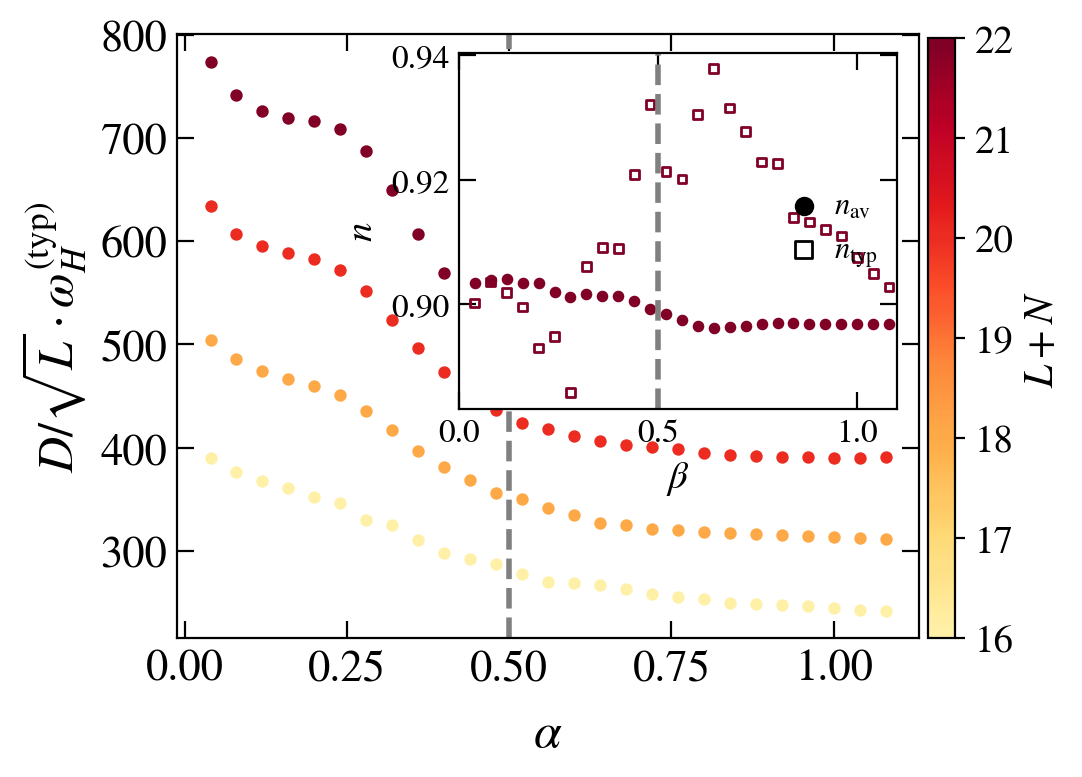

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0


INTEGRATED = 0
BC = 0

prefix = '../results_fgr/symmetries/OBC/Spectrals_SzSz/' if BC else '../results_fgr/symmetries/PBC/Spectrals_SzSz/'
hz = 0

sizes = np.arange(16, 23, 2)
dx_vals = np.arange(0.04, 1.09, 0.04)
dx_crit = 0.5


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5, 4), dpi = 200, sharex=True)
inset = axis.inset_axes([0.38, 0.38, 0.59, 0.59])

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

iddx = -2
qs = [0.5, 1.0, 1.5, 2, 3.0]
q = qs[iddx]

wH_all = []
wH_typ_all = []
dims = []
for L in sizes:
    col = s_m.to_rgba(L)
    
    wH       = np.zeros((dx_vals.size))
    wH_typ    = np.zeros((dx_vals.size))
    real_sec, imag_sec = get_sectors(L, BC, hz)
    
    for ii, dx in enumerate(dx_vals):
        dim_tot = 0
        counter = 0
        for [ks, ps, zxs] in imag_sec:
        # for [ks, ps, zxs] in real_sec:
        # for [ks, ps, zxs] in [[0,1,1]]:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            name = prefix + info_sym(L=L, J1=J, delta1=delta, delta2=dx, k=ks, p=ps, zx=zxs) + '.hdf5'
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    counter += 1
                    E = np.array(file.get('energies'))[0]
                    dim = E.size
                    
                    dim_tot += factor * dim
                    Etarget = np.mean(E)#E[0] + 0.2 * (E[-1] - E[0])
                    
                    idxE = np.argmin(np.abs(E - Etarget))
                    num = int( min(500, 0.1*dim) )
                    num = dim//2
                    
                    idx_min = idxE - num//2
                    if idx_min < 0: idx_min = 0
                    idx_max = idxE + num//2
                    if idx_max > dim-1: idx_max = dim
                    
                    # print(idxE, idxE - num//2, idxE + num//2)
                    # pr[ii] = np.mean(np.array(file.get('Pr_q'))[iddx])
                    wH[ii] += np.mean( np.abs(np.diff(E)[idx_min : idx_max])) / np.sqrt(L)# * factor * dim / np.sqrt(L)
                    wH_typ[ii] += np.exp( np.mean( np.log( np.diff(E)[idx_min : idx_max]))) / np.sqrt(L)# * factor * dim / np.sqrt(L)
                    
            else:
                print(name)
        # wH[ii] /= dim_tot
        # wH_typ[ii] /= dim_tot
    # print(L, Sinfo)
    dims.append(dim_tot / counter)
    axis.scatter(dx_vals, dim_tot * wH_typ, color=col, s=12)
    
    wH_all.append(wH)
    wH_typ_all.append(wH_typ)

wH_all = np.transpose(np.array(wH_all))
wH_typ_all = np.transpose(np.array(wH_typ_all))
dims = np.array(dims)

n = np.zeros( (dx_vals.size) )
n_typ = np.zeros( (dx_vals.size) )

def _fun_pr(D, a, d2):
    return a * D**(-d2)

def _fun_info(L, a, d2):
    return d2 * L + a


for ii, dx in enumerate(dx_vals):
    parsolo, pconv, fit_info, msg, _ = fit(_fun_pr,
                        xdata = dims,
                        ydata = wH_all[ii],
                        full_output=True, maxfev=20000)
    A = parsolo[0]
    n[ii] = parsolo[1]
    
    parsolo, pconv, fit_info, msg, _ = fit(_fun_pr,
                        xdata = dims,
                        ydata = wH_typ_all[ii],
                        full_output=True, maxfev=20000)
    A = parsolo[0]
    n_typ[ii] = parsolo[1]
    
inset.scatter(dx_vals, n, color=col, s=10)
inset.scatter(dx_vals, n_typ, color=col, marker='s', facecolor='None', s=10)
        
        
inset.scatter(np.nan, np.nan, color='k', label=r"$n_{\rm av}$")  
inset.scatter(np.nan, np.nan, color='k', label=r"$n_{\rm typ}$", marker='s', facecolor='None')

axis.axvline(x=dx_crit, ls='--', color='gray', lw=2)
inset.axvline(x=dx_crit, ls='--', color='gray', lw=2)
# inset.axhline(y=0, ls='-', color='blue', lw=2)

# inset.xaxis.set_ticks_position('top')
# inset.xaxis.set_label_position('top')
# inset.yaxis.set_ticks_position('right')
# inset.yaxis.set_label_position('right')

fig_help.set_plot_elements(axis, ylabel=r"$D/\sqrt{L}\cdot\omega_H^{\rm (typ)}$", xlabel=r"$\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# axis.set_ylim(0, 6÷)

fig_help.set_plot_elements(inset, ylabel=r"$n$", xlabel=r"$\beta$", font_size=12, set_legend=1, xscale='linear', yscale='linear')
fig_help.set_legend(inset, fontsize=11, loc='center right', ncol=1)
inset.set_xlim(0, 1.1)
# inset.set_ylim(-0.1, 1)

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.125, 0.03, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$L+N$", fontsize=15)
cbar.ax.tick_params(labelsize=14)

fig.subplots_adjust(wspace = 0.03, hspace=0.03)
# fig.savefig("../../Quadratic/Jupyter_Python/PLOTS_FADING/BEYOND_RMT/Fig_d2_QSM.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [333]:
1 / 2.55

0.3921568627450981